In [2]:
import sys
!{sys.executable} -m pip install gymnasium

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from IPython.display import clear_output, display



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
print(env.action_space)
print(env.observation_space)
print(env.action_space.sample())

Discrete(3)
Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
1


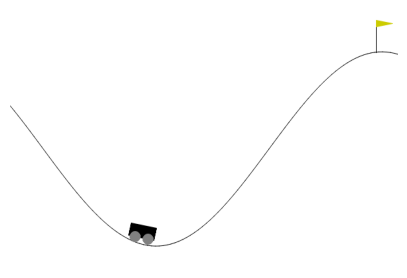

KeyboardInterrupt: 

In [19]:
obs, info = env.reset()
done = False

for _ in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    clear_output(wait=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    time.sleep(0.01)
env.close()


# How mountain car act

In [29]:
obs, info = env.reset()

done = False
while not done:
   env.render()
   obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
   done = terminated or truncated
   print(f"{obs} -> {rew}")
   
env.close()

[-5.5282700e-01  2.2057892e-04] -> -1.0
[-5.523875e-01  4.395099e-04] -> -1.0
[-0.55173236  0.00065516] -> -1.0
[-5.518664e-01 -1.340916e-04] -> -1.0
[-0.55078876  0.00107766] -> -1.0
[-0.54950744  0.00128136] -> -1.0
[-0.5480319   0.00147548] -> -1.0
[-0.5453734   0.00265856] -> -1.0
[-0.5435516   0.00182176] -> -1.0
[-0.5415803   0.00197131] -> -1.0
[-0.5394742   0.00210611] -> -1.0
[-0.5382491   0.00122513] -> -1.0
[-0.53591406  0.00233497] -> -1.0
[-0.5344868   0.00142732] -> -1.0
[-5.339778e-01  5.089624e-04] -> -1.0
[-0.533391    0.00058679] -> -1.0
[-0.53273076  0.00066022] -> -1.0
[-0.5310021   0.00172871] -> -1.0
[-0.52921784  0.00178423] -> -1.0
[-0.5283915   0.00082637] -> -1.0
[-0.5265292   0.00186231] -> -1.0
[-0.5246449   0.00188429] -> -1.0
[-0.52375275  0.00089213] -> -1.0
[-0.52285945  0.00089329] -> -1.0
[-0.5219717   0.00088774] -> -1.0
[-0.52109617  0.00087554] -> -1.0
[-0.5202394   0.00085677] -> -1.0
[-0.5194078   0.00083158] -> -1.0
[-0.5186077   0.00080015] -> -

In [30]:
print(env.observation_space.low)
print(env.observation_space.high)

[-1.2  -0.07]
[0.6  0.07]


# State Discretization

# Q-Table Structure

In [9]:
Q = {}
actions = (0,1,2)

def qvalues(state):
    return [Q.get((state,a),0) for a in actions]

In [10]:
# hyperparameters

alpha = 0.1
gamma = 0.9
epsilon = 0.95

In [ ]:
def probs(v,eps=1e-4):
    v = v-v.min()+eps
    v = v/v.sum()
    return v

Qmax = 0
cum_rewards = []
rewards = []
for epoch in range(100000):
    obs, info = env.reset()
    done = False
    cum_reward=0
    # == do the simulation ==
    while not done:
        s = discretize(obs)
        if random.random()<epsilon:
            # exploitation - chose the action according to Q-Table probabilities
            v = probs(np.array(qvalues(obs)))
            a = random.choices(actions,weights=v)[0]
        else:
            # exploration - randomly chose the action
            a = np.random.randint(env.action_space.n)

        obs, rew, terminated, truncated, info = env.step(a)
        done = terminated or truncated
        cum_reward+=rew
        ns = discretize(obs)
        Q[(s,a)] = (1 - alpha) * Q.get((s,a),0) + alpha * (rew + gamma * max(qvalues(ns)))
    cum_rewards.append(cum_reward)
    rewards.append(cum_reward)
    # == Periodically print results and calculate average reward ==
    if epoch%5000==0:
        print(f"{epoch}: {np.average(cum_rewards)}, alpha={alpha}, epsilon={epsilon}")
        if np.average(cum_rewards) > Qmax:
            Qmax = np.average(cum_rewards)
            Qbest = Q
        cum_rewards=[]

TypeError: unhashable type: 'numpy.ndarray'